In [1]:
import sys
import os



sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:

x1 = pd.read_csv(f"mod_data/X1.{10}", index_col="QSPRID")
x1

,300,301,302,303,304,305,306,307,308,309,...,RDkit_fr_priamide,RDkit_fr_pyridine,RDkit_fr_sulfide,RDkit_fr_sulfonamd,RDkit_fr_sulfone,RDkit_fr_thiazole,RDkit_fr_thiophene,RDkit_fr_unbrch_alkane,RDkit_fr_urea,RDkit_qed
QSPRID,,,,,,,,,,,,,,,,,,,,,
A2ARDataset_0000,-0.308563,0.516990,0.283642,0.266294,-0.247365,-1.128524,0.309840,-0.524603,-0.147377,-0.032262,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.719563
A2ARDataset_0001,-0.640036,0.455878,0.328034,-0.047239,-0.111043,-0.716582,0.109168,-0.524060,-0.022254,0.504825,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.537523
A2ARDataset_0002,-0.451369,0.486193,0.424564,0.149110,0.617608,-0.734653,0.313663,-0.647633,-0.204602,0.041710,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.608309
A2ARDataset_0003,-0.725623,0.673051,0.076636,-0.020468,0.330413,-0.682617,0.611409,-0.071810,0.751207,0.070477,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.468174
A2ARDataset_0004,-0.470729,0.549438,0.277636,-0.085926,0.414889,-0.722803,0.249775,-0.376355,0.256691,-0.062559,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.665933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2ARDataset_2393,-0.320582,0.624884,0.077183,0.139234,0.043471,-0.632272,0.603211,0.004710,0.099075,0.059412,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.418088
A2ARDataset_2394,-0.852284,0.457375,-0.038807,-0.106715,-0.018903,-0.839702,0.369481,-0.082639,0.462854,0.082954,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.377890
A2ARDataset_2395,-0.354825,0.423986,0.378059,-0.071413,-0.170156,-0.951851,0.188338,0.132632,0.305014,0.269345,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.416563


In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X1)


PCA(n_components=0.95)

In [6]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1
n_components

851

In [7]:
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

In [8]:
X1.shape

(2407, 851)

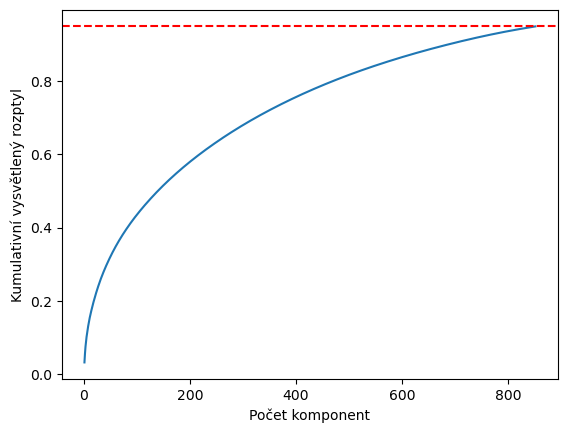

In [9]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [10]:
import importlib
# This part of your code directly loads MLP.py
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py'
module_name_for_direct_load = 'my_local_MLP_module' # Can be any unique name
spec = importlib.util.spec_from_file_location(module_name_for_direct_load, module_path)
if spec and spec.loader:
    neural_network = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(neural_network)
    MultiLayerPerceptron = neural_network.MultiLayerPerceptron
    print(f"Successfully loaded MLP directly from {module_path}")
else:
    print(f"Could not create spec for module at {module_path}")

lol
Successfully loaded MLP directly from /home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/MLP.py


In [11]:
output_dir = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/A2AR/modelshyperparameter_tuning_results'
csv_filename = os.path.join(output_dir, 'A2AR_mlp_without_smote.csv')
df_existing = pd.read_csv(csv_filename)

In [12]:
df_existing = df_existing.sort_values(by="mcc", ascending=False)

In [13]:
display(df_existing)


,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
862,863,0.458286,0.983482,0.967941,86.219639,0.575294,189,0.002121,0.000720,975,1024,AdamW,0.0100,"[4096, 3072, 2048, 1536, 1024, 768, 512, 256, ..."
358,359,0.418606,0.980217,0.961776,60.131718,0.636073,105,0.000126,0.007543,1252,128,AdamW,0.0100,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
437,438,0.414514,0.972868,0.948212,18.113535,0.034556,13,0.000012,0.001456,764,256,RMSprop,0.0010,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
128,129,0.401867,0.984247,0.969174,38.546190,0.218418,22,0.001207,0.002947,927,512,RMSprop,0.1000,"[4000, 2000, 2000, 500]"
202,203,0.369800,0.976297,0.954377,34.579458,0.397152,74,0.002121,0.015264,904,1024,AdamW,0.0100,"[4096, 3072, 2048, 1536, 1024, 768, 512, 256, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,961,-0.086110,0.858351,0.752158,4.323728,0.843314,11,0.000295,0.000356,998,256,AdamW,0.0100,"[2000, 1000, 500]"
958,959,-0.094331,0.783133,0.644883,35.430959,0.540870,94,0.005690,0.000021,395,1024,RMSprop,0.0010,"[4096, 3072, 2048, 1536, 1024, 768, 512, 256, ..."
579,580,-0.095852,0.356108,0.233046,30.526868,0.690188,18,0.001048,0.000069,1328,128,RMSprop,0.0001,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
598,599,-0.113290,0.255507,0.166461,23.837953,0.482999,95,0.001389,0.062506,1958,1024,RMSprop,0.0100,"[2000, 1000, 500]"


In [14]:
display(df_existing.iloc[0])

run_id                                                            863
mcc                                                          0.458286
f1                                                           0.983482
acc                                                          0.967941
duration_seconds                                            86.219639
dropout_frac                                                 0.575294
patience                                                          189
tol                                                          0.002121
weight_decay                                                  0.00072
n_epochs                                                          975
batch_size                                                       1024
optimizer                                                       AdamW
lr                                                               0.01
neuron_layers       [4096, 3072, 2048, 1536, 1024, 768, 512, 256, ...
Name: 862, dtype: ob

In [15]:
df_existing

,run_id,mcc,f1,acc,duration_seconds,dropout_frac,patience,tol,weight_decay,n_epochs,batch_size,optimizer,lr,neuron_layers
862,863,0.458286,0.983482,0.967941,86.219639,0.575294,189,0.002121,0.000720,975,1024,AdamW,0.0100,"[4096, 3072, 2048, 1536, 1024, 768, 512, 256, ..."
358,359,0.418606,0.980217,0.961776,60.131718,0.636073,105,0.000126,0.007543,1252,128,AdamW,0.0100,"[2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
437,438,0.414514,0.972868,0.948212,18.113535,0.034556,13,0.000012,0.001456,764,256,RMSprop,0.0010,"[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]"
128,129,0.401867,0.984247,0.969174,38.546190,0.218418,22,0.001207,0.002947,927,512,RMSprop,0.1000,"[4000, 2000, 2000, 500]"
202,203,0.369800,0.976297,0.954377,34.579458,0.397152,74,0.002121,0.015264,904,1024,AdamW,0.0100,"[4096, 3072, 2048, 1536, 1024, 768, 512, 256, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,961,-0.086110,0.858351,0.752158,4.323728,0.843314,11,0.000295,0.000356,998,256,AdamW,0.0100,"[2000, 1000, 500]"
958,959,-0.094331,0.783133,0.644883,35.430959,0.540870,94,0.005690,0.000021,395,1024,RMSprop,0.0010,"[4096, 3072, 2048, 1536, 1024, 768, 512, 256, ..."
579,580,-0.095852,0.356108,0.233046,30.526868,0.690188,18,0.001048,0.000069,1328,128,RMSprop,0.0001,"[4096, 2048, 1024, 512, 256, 512, 1024, 2048, ..."
598,599,-0.113290,0.255507,0.166461,23.837953,0.482999,95,0.001389,0.062506,1958,1024,RMSprop,0.0100,"[2000, 1000, 500]"


In [16]:
best_results = df_existing.iloc[:10]

In [17]:
best_results = best_results.iloc[:, 5:]

In [18]:
best_results_dicts = []
for i,j in best_results.iterrows():
    best_results_dicts.append(dict(j))

In [19]:
best_results_dicts

[{'dropout_frac': 0.5752938472659872,
  'patience': 189,
  'tol': 0.0021209508879201,
  'weight_decay': 0.0007196856730011,
  'n_epochs': 975,
  'batch_size': 1024,
  'optimizer': 'AdamW',
  'lr': 0.01,
  'neuron_layers': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'},
 {'dropout_frac': 0.6360725637208794,
  'patience': 105,
  'tol': 0.0001264855216855,
  'weight_decay': 0.0075431200633546,
  'n_epochs': 1252,
  'batch_size': 128,
  'optimizer': 'AdamW',
  'lr': 0.01,
  'neuron_layers': '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]'},
 {'dropout_frac': 0.0345555676963508,
  'patience': 13,
  'tol': 1.151395399326448e-05,
  'weight_decay': 0.0014563484775012,
  'n_epochs': 764,
  'batch_size': 256,
  'optimizer': 'RMSprop',
  'lr': 0.001,
  'neuron_layers': '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]'},
 {'dropout_frac': 0.2184177117739372,
  'patience': 22,
  'tol': 0.0012067926406393,
  'weight_decay': 0.0029470517025518,
  'n_epochs': 927,
  'batch_size': 51

In [20]:

df_existing_svc = pd.read_csv("res/svc_without_smote_res_val_1.1.csv")
display(df_existing_svc)
df_existing_svc = df_existing_svc.sort_values(by="mcc", ascending=False)
df_existing_svc = df_existing_svc.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_svc = df_existing_svc.iloc[:, :6]

best_results_svc_dicts = []
for i,j in df_existing_svc.iterrows():
    best_results_svc_dicts.append(dict(j))
    

,Unnamed: 0,C,coef0,degree,gamma,kernel,shrinking,mcc,f1,acc
0,2310,1.0,0.0,2,scale,sigmoid,True,0.443170,0.984848,0.970407
1,2311,1.0,0.0,2,scale,sigmoid,False,0.443170,0.984848,0.970407
2,2358,1.0,0.0,3,scale,sigmoid,True,0.443170,0.984848,0.970407
3,2359,1.0,0.0,3,scale,sigmoid,False,0.443170,0.984848,0.970407
4,2406,1.0,0.0,4,scale,sigmoid,True,0.443170,0.984848,0.970407
...,...,...,...,...,...,...,...,...,...,...
5371,3167,10.0,0.0,3,1,sigmoid,False,-0.035669,0.964240,0.930949
5372,3214,10.0,0.0,4,1,sigmoid,True,-0.035669,0.964240,0.930949
5373,3215,10.0,0.0,4,1,sigmoid,False,-0.035669,0.964240,0.930949
5374,3262,10.0,0.0,5,1,sigmoid,True,-0.035669,0.964240,0.930949


In [21]:
best_results_svc_dicts

[{'C': 1.0,
  'coef0': 0.0,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 0.0,
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 0.0,
  'degree': 3,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 0.0,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 0.0,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 0.0,
  'degree': 5,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 0.0,
  'degree': 5,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 0.0,
  'degree': 2,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': False},
 {'C': 1.0,
  'coef0': 0.1,
  'degree': 4,
  'gamma': 'scale',
  'kernel': 'sigmoid',
  'shrinking': True},
 {'C': 1.0,
  'coef0': 0

In [22]:
df_existing_knn = pd.read_csv("res/knn_without_smote_res_val_1.1.csv")
df_existing_knn = df_existing_knn.sort_values(by="mcc", ascending=False)
df_existing_knn = df_existing_knn.iloc[:10].drop("Unnamed: 0", axis=1)
df_existing_knn = df_existing_knn.iloc[:, :6]
best_results_knn_dicts = []
for i,j in df_existing_knn.iterrows():
    best_results_knn_dicts.append(dict(j))

In [23]:
best_results_knn_dicts

[{'algorithm': 'auto',
  'leaf_size': 10,
  'metric': 'euclidean',
  'n_neighbors': 5,
  'p': 1,
  'weights': 'uniform'},
 {'algorithm': 'kd_tree',
  'leaf_size': 10,
  'metric': 'euclidean',
  'n_neighbors': 5,
  'p': 1,
  'weights': 'distance'},
 {'algorithm': 'brute',
  'leaf_size': 10,
  'metric': 'euclidean',
  'n_neighbors': 5,
  'p': 1,
  'weights': 'uniform'},
 {'algorithm': 'kd_tree',
  'leaf_size': 100,
  'metric': 'minkowski',
  'n_neighbors': 5,
  'p': 2,
  'weights': 'distance'},
 {'algorithm': 'kd_tree',
  'leaf_size': 100,
  'metric': 'minkowski',
  'n_neighbors': 5,
  'p': 2,
  'weights': 'uniform'},
 {'algorithm': 'kd_tree',
  'leaf_size': 100,
  'metric': 'euclidean',
  'n_neighbors': 5,
  'p': 2,
  'weights': 'distance'},
 {'algorithm': 'kd_tree',
  'leaf_size': 100,
  'metric': 'euclidean',
  'n_neighbors': 5,
  'p': 2,
  'weights': 'uniform'},
 {'algorithm': 'kd_tree',
  'leaf_size': 100,
  'metric': 'euclidean',
  'n_neighbors': 5,
  'p': 1,
  'weights': 'distance

SVC
0.44317007044298046
0.44317007044298046
0.44317007044298046
0.44317007044298046
0.44317007044298046
0.44317007044298046
0.44317007044298046
0.44317007044298046
0.3642604310382038
0.3642604310382038
KNN
0.40546164961140646
0.40546164961140646
0.40546164961140646
0.40546164961140646
0.40546164961140646
0.40546164961140646
0.40546164961140646
0.40546164961140646
0.40546164961140646
0.40546164961140646
RESULTS FOR CYCLE KNN#1
Accuracy: 0.9653
F1-Score: 0.9823
MCC: 0.1733
RESULTS FOR CYCLE SVC#1
Accuracy: 0.9722
F1-Score: 0.9858
MCC: 0.4437


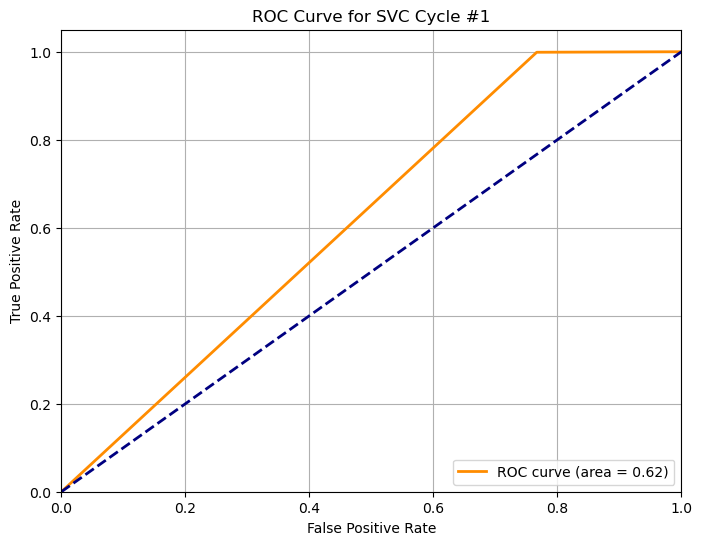

0.22416707382680096
0.36420704618389593
0.26983742720892784
0.0
0.15714925283600678
0.2719080189714195
0.36180090261601267
0.3192348482635313
0.4033800474779824
0.16433057941609858
RESULTS FOR CYCLE MLP#1
Accuracy: 0.8553
F1-Score: 0.9209
MCC: 0.1282


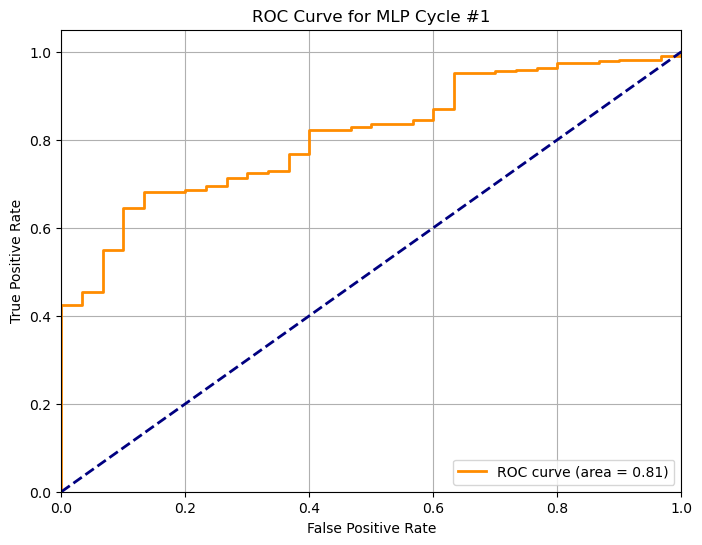

SVC
0.3127623480533702
0.3127623480533702
0.3127623480533702
0.3127623480533702
0.3127623480533702
0.3127623480533702
0.3127623480533702
0.3127623480533702
0.2611994580836813
0.2611994580836813
KNN
0.2592498180213119
0.2592498180213119
0.2592498180213119
0.2592498180213119
0.2592498180213119
0.2592498180213119
0.2592498180213119
0.2592498180213119
0.2592498180213119
0.2592498180213119
RESULTS FOR CYCLE KNN#2
Accuracy: 0.9670
F1-Score: 0.9832
MCC: 0.1795
RESULTS FOR CYCLE SVC#2
Accuracy: 0.9658
F1-Score: 0.9825
MCC: 0.3264


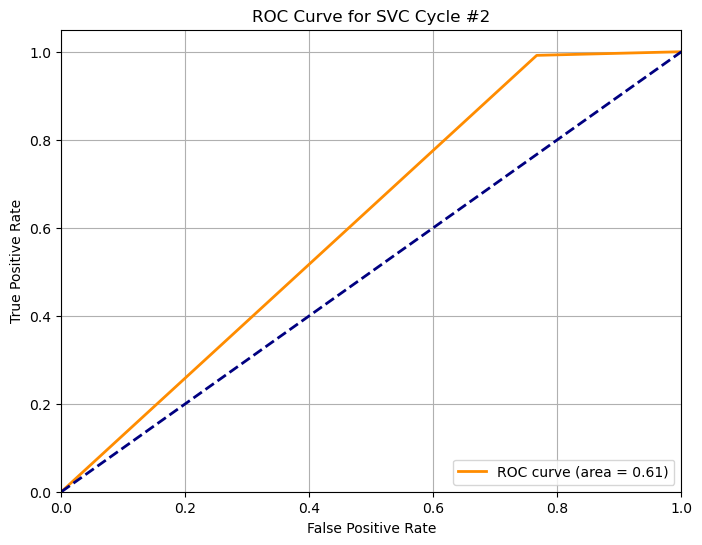

0.07652753646005571
0.2083032868908656
0.18419104291350996
0.007139479731674114
0.10092928238794349
0.3053233061355858
0.2521975881726024
0.2172928231858595
0.0
0.15859909113976206
RESULTS FOR CYCLE MLP#2
Accuracy: 0.8531
F1-Score: 0.9186
MCC: 0.2763


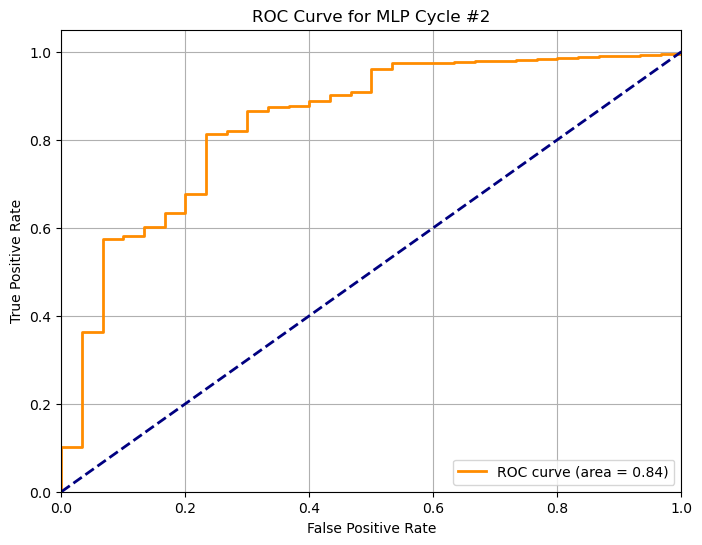

SVC
0.20319947456907514
0.20319947456907514
0.20319947456907514
0.20319947456907514
0.20319947456907514
0.20319947456907514
0.20319947456907514
0.20319947456907514
0.12189184098248813
0.12189184098248813
KNN
0.19220582211636572
0.20273882620949712
0.19220582211636572
0.20273882620949712
0.19220582211636572
0.20273882620949712
0.19220582211636572
0.20273882620949712
0.19220582211636572
0.20273882620949712
RESULTS FOR CYCLE KNN#3
Accuracy: 0.9622
F1-Score: 0.9807
MCC: 0.1240
RESULTS FOR CYCLE SVC#3
Accuracy: 0.9667
F1-Score: 0.9830
MCC: 0.3402


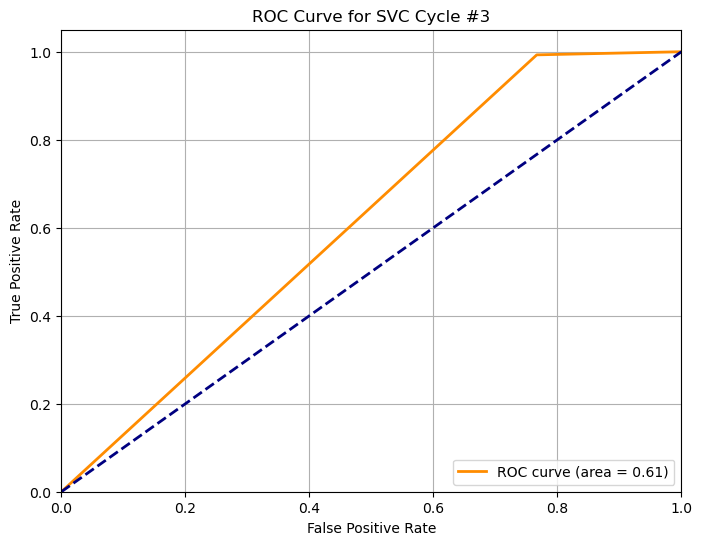

0.08467917894462523
0.43329053923137945
0.2171826458462882
0.0911436922549968
0.2843754479747182
0.30717680142891673
0.2619405394755675
0.3696767163278451
0.19354974548473333
0.3783618538356402
RESULTS FOR CYCLE MLP#3
Accuracy: 0.9404
F1-Score: 0.9688
MCC: 0.2932


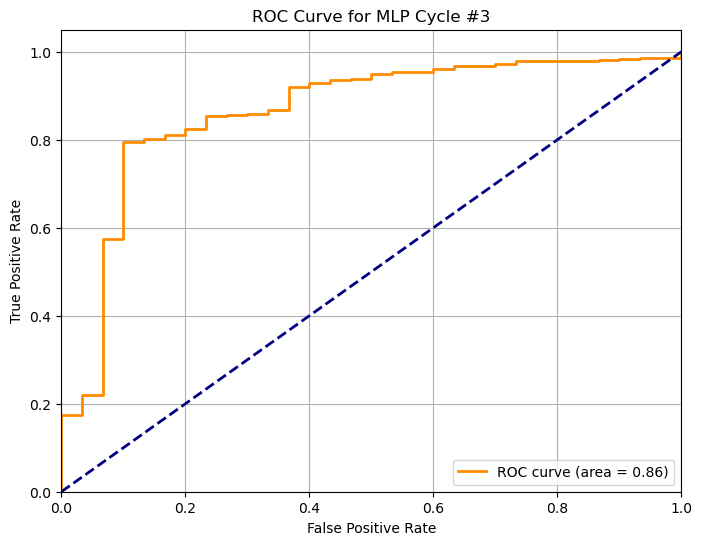

SVC
0.6510112719003086
0.6510112719003086
0.6510112719003086
0.6510112719003086
0.6510112719003086
0.6510112719003086
0.6510112719003086
0.6510112719003086
0.5698713229785517
0.5698713229785517
KNN
0.5254201620973783
0.48853788767773904
0.5254201620973783
0.48853788767773904
0.5254201620973783
0.48853788767773904
0.5254201620973783
0.48853788767773904
0.5254201620973783
0.48853788767773904
RESULTS FOR CYCLE KNN#4
Accuracy: 0.9649
F1-Score: 0.9822
MCC: -0.0063
RESULTS FOR CYCLE SVC#4
Accuracy: 0.9661
F1-Score: 0.9827
MCC: 0.0000


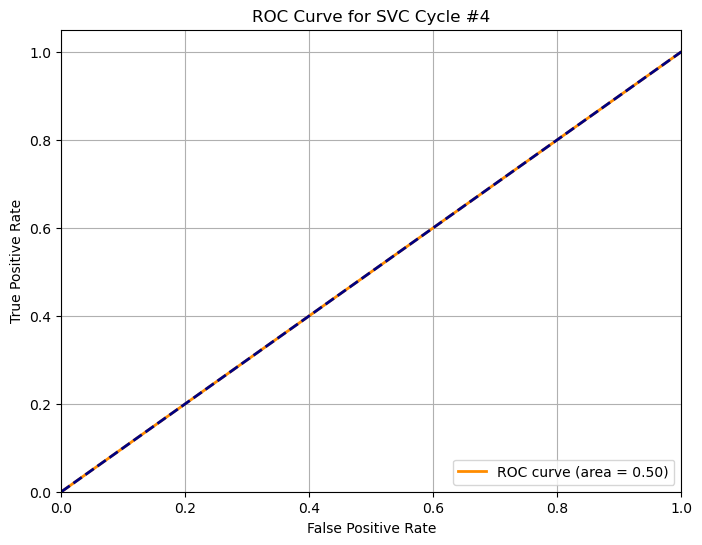

0.39558082821108076
0.3485202411173066
0.2526039188360267
0.0
0.22496382588743497
0.44382555588371525
0.37513938807804253
0.34611753016938557
0.45577830277723874
0.44382555588371525
RESULTS FOR CYCLE MLP#4
Accuracy: 0.8462
F1-Score: 0.9153
MCC: 0.1494


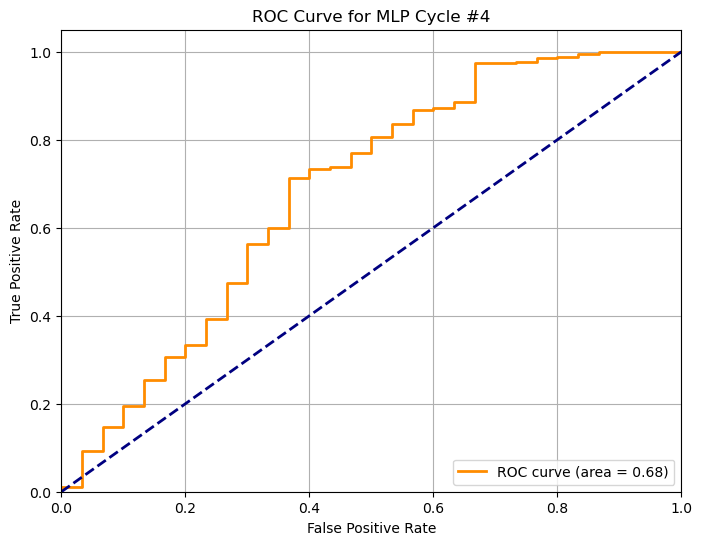

SVC
0.16568713995731638
0.16568713995731638
0.16568713995731638
0.16568713995731638
0.16568713995731638
0.16568713995731638
0.16568713995731638
0.16568713995731638
0.1781656334884801
0.1781656334884801
KNN
0.04084231959391639
0.0364953297043435
0.04084231959391639
0.0364953297043435
0.04084231959391639
0.0364953297043435
0.04084231959391639
0.0364953297043435
0.04084231959391639
0.0364953297043435
RESULTS FOR CYCLE KNN#5
Accuracy: 0.9643
F1-Score: 0.9818
MCC: 0.1393
RESULTS FOR CYCLE SVC#5
Accuracy: 0.9770
F1-Score: 0.9882
MCC: 0.5752


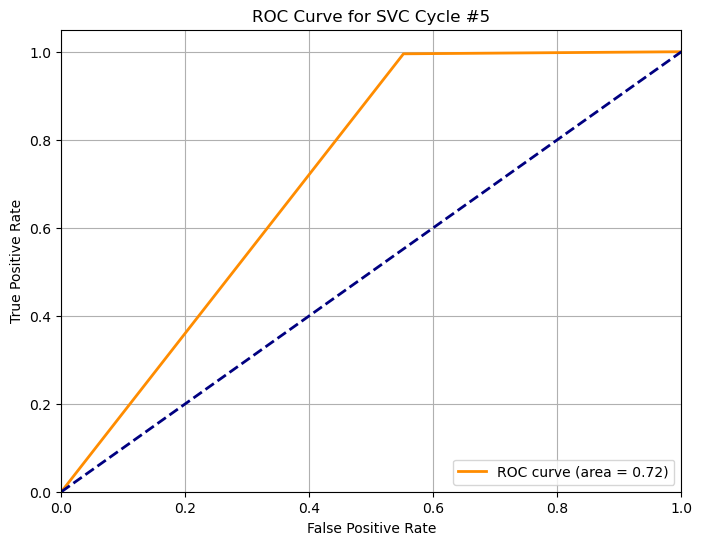

0.26000862836330063
0.0
0.22039223287397486
0.0
0.14991660460188794
0.38162900122908316
0.20045864374497221
0.3408213989425849
0.0
0.35253790010978
RESULTS FOR CYCLE MLP#5
Accuracy: 0.8746
F1-Score: 0.9313
MCC: 0.3122


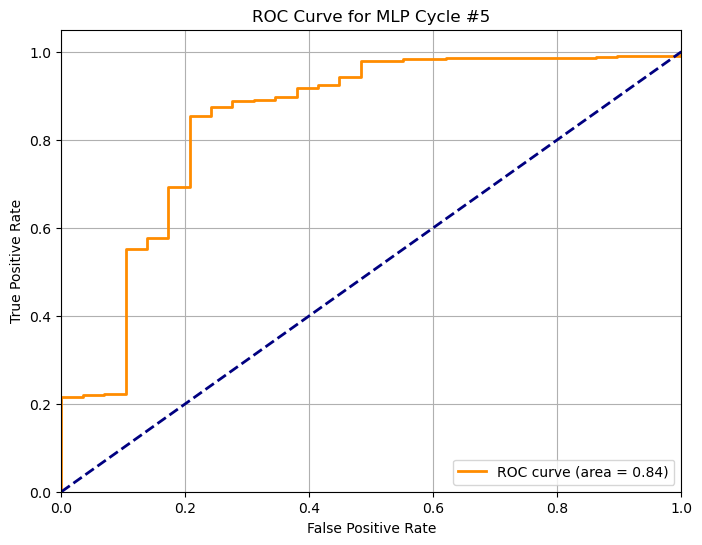

SVC
0.3639538820773332
0.3639538820773332
0.3639538820773332
0.3639538820773332
0.3639538820773332
0.3639538820773332
0.3639538820773332
0.3639538820773332
0.20301134724448644
0.20301134724448644
KNN
0.37190193815226813
0.37190193815226813
0.37190193815226813
0.37190193815226813
0.37190193815226813
0.37190193815226813
0.37190193815226813
0.37190193815226813
0.37190193815226813
0.37190193815226813
RESULTS FOR CYCLE KNN#6
Accuracy: 0.9656
F1-Score: 0.9825
MCC: -0.0063
RESULTS FOR CYCLE SVC#6
Accuracy: 0.9679
F1-Score: 0.9836
MCC: 0.2400


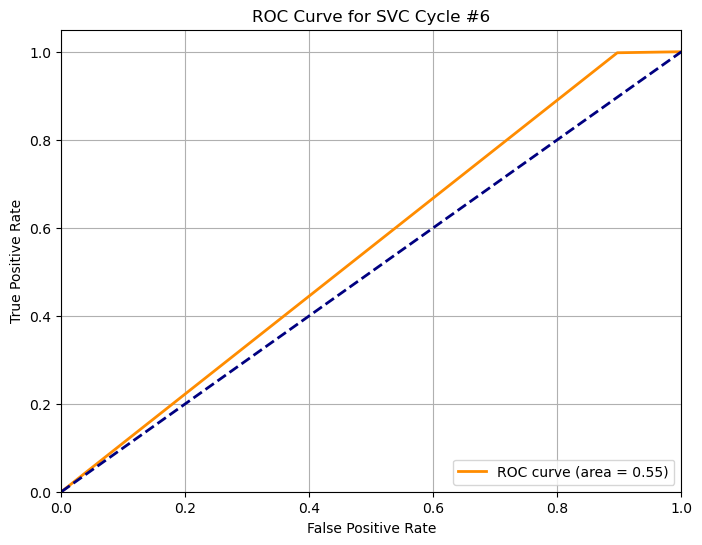

0.4893126891401867
0.4698896315085928
0.25440345032614753
0.06126765456792816
0.29886099066060046
0.3550100278864147
0.28723486692749955
0.3766703430173846
0.23385963651457253
0.39945182195757795
RESULTS FOR CYCLE MLP#6
Accuracy: 0.9610
F1-Score: 0.9800
MCC: 0.1883


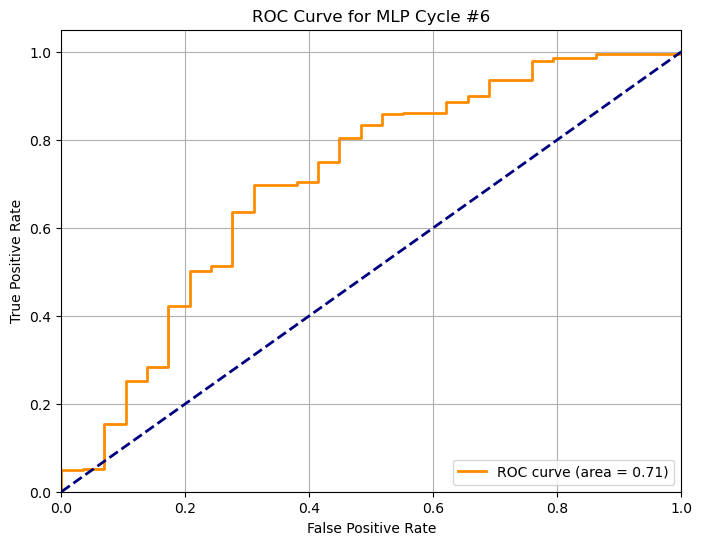

SVC
0.13525602322456012
0.13525602322456012
0.13525602322456012
0.13525602322456012
0.13525602322456012
0.13525602322456012
0.13525602322456012
0.13525602322456012
0.17249448232736067
0.17249448232736067
KNN
0.11228618303594223
0.13525602322456012
0.11228618303594223
0.13525602322456012
0.11228618303594223
0.13525602322456012
0.11228618303594223
0.13525602322456012
0.11228618303594223
0.13525602322456012
RESULTS FOR CYCLE KNN#7
Accuracy: 0.9642
F1-Score: 0.9817
MCC: 0.1522
RESULTS FOR CYCLE SVC#7
Accuracy: 0.9711
F1-Score: 0.9852
MCC: 0.4164


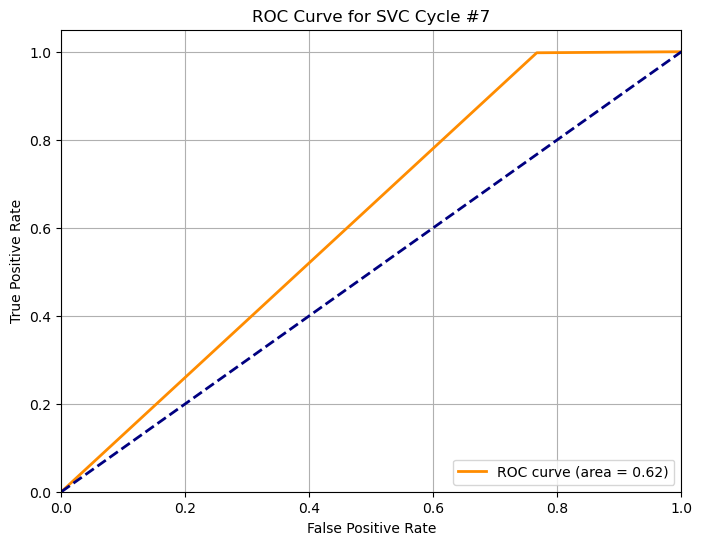

0.20322862129144853
0.13747529828541993
0.1576844615406918
0.0
0.25699253802212807
0.2436548736924201
0.20142498783770632
0.24511734035440022
0.0
0.1877908934562251
RESULTS FOR CYCLE MLP#7
Accuracy: 0.9006
F1-Score: 0.9465
MCC: 0.3195


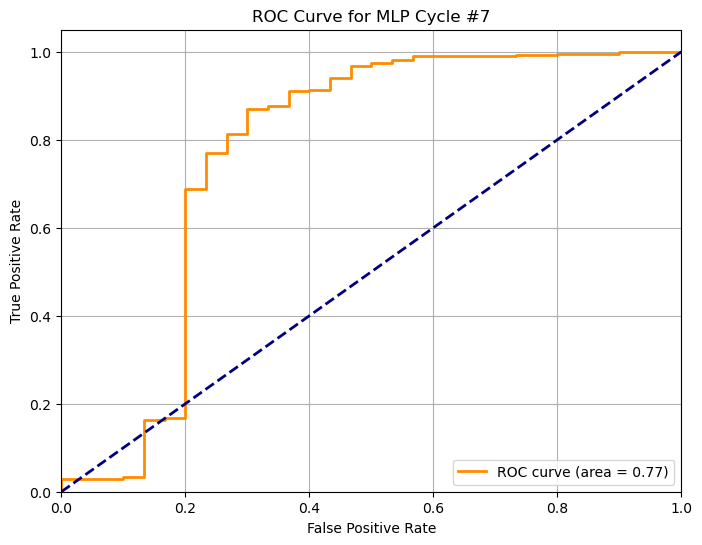

SVC
0.1990279616982372
0.1990279616982372
0.1990279616982372
0.1990279616982372
0.1990279616982372
0.1990279616982372
0.1990279616982372
0.1990279616982372
0.2245441504512285
0.2245441504512285
KNN
0.2462870982593483
0.2868623535130954
0.2462870982593483
0.2868623535130954
0.2462870982593483
0.2868623535130954
0.2462870982593483
0.2868623535130954
0.2462870982593483
0.2868623535130954
RESULTS FOR CYCLE KNN#8
Accuracy: 0.9717
F1-Score: 0.9855
MCC: 0.4062
RESULTS FOR CYCLE SVC#8
Accuracy: 0.9683
F1-Score: 0.9838
MCC: 0.3344


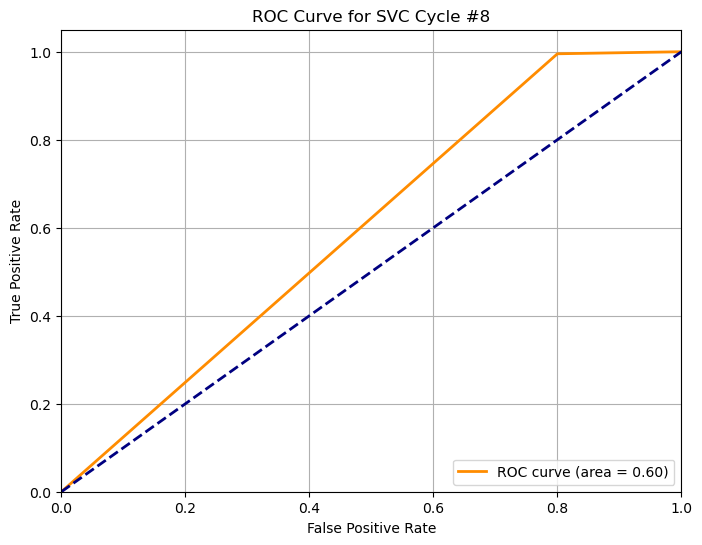

0.27844241697520855
0.3289758474798845
0.276286669934014
0.0
0.3224608291466229
0.35244498873176183
0.31034795188396774
0.33008528322886593
0.20556269327299284
0.3232607191682807
RESULTS FOR CYCLE MLP#8
Accuracy: 0.8288
F1-Score: 0.9046
MCC: 0.1638


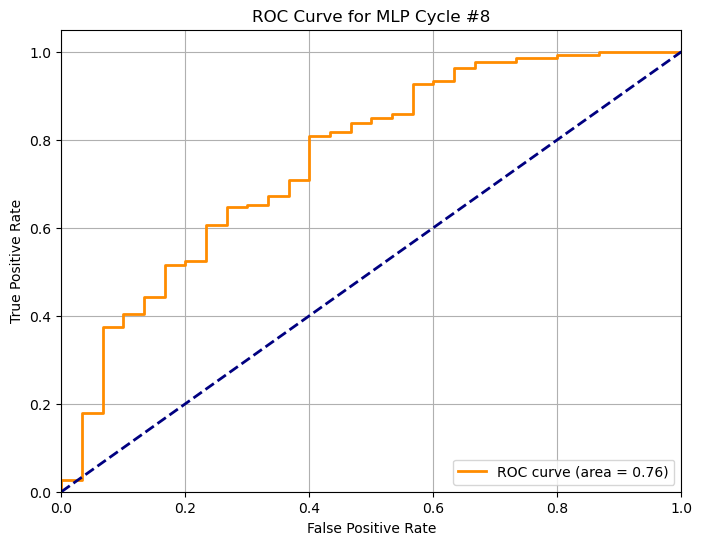

SVC
0.7085084970439103
0.7085084970439103
0.7085084970439103
0.7085084970439103
0.7085084970439103
0.7085084970439103
0.7085084970439103
0.7085084970439103
0.6849809113654483
0.6849809113654483
KNN
0.3724257776201712
0.35479876837696545
0.3724257776201712
0.35479876837696545
0.3724257776201712
0.35479876837696545
0.3724257776201712
0.35479876837696545
0.3724257776201712
0.35479876837696545
RESULTS FOR CYCLE KNN#9
Accuracy: 0.9704
F1-Score: 0.9849
MCC: 0.3417
RESULTS FOR CYCLE SVC#9
Accuracy: 0.9647
F1-Score: 0.9820
MCC: -0.0088


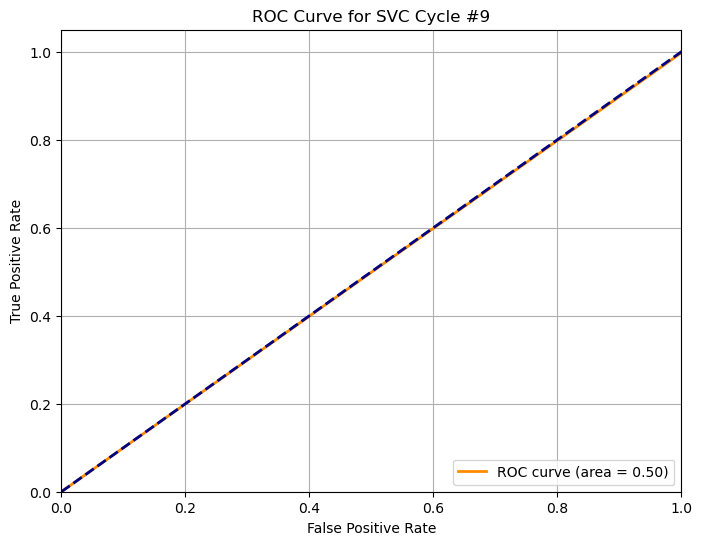

0.22972196701695674
0.6191634790917409
0.2904555980579383
0.28829480631320503
0.38256905515557704
0.3907840717916107
0.3287215950009602
0.3260187535036973
0.3865802992914709
0.38058424940406055
RESULTS FOR CYCLE MLP#9
Accuracy: 0.9328
F1-Score: 0.9650
MCC: 0.1124


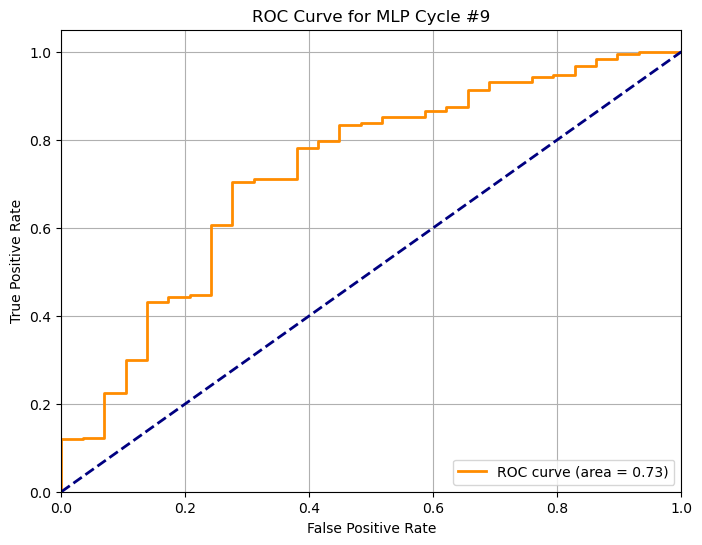

SVC
0.5468335298293572
0.5468335298293572
0.5468335298293572
0.5468335298293572
0.5468335298293572
0.5468335298293572
0.5468335298293572
0.5468335298293572
0.5414996187423823
0.5414996187423823
KNN
0.44269376238283237
0.44269376238283237
0.44269376238283237
0.44269376238283237
0.44269376238283237
0.44269376238283237
0.44269376238283237
0.44269376238283237
0.44269376238283237
0.44269376238283237
RESULTS FOR CYCLE KNN#10
Accuracy: 0.9578
F1-Score: 0.9784
MCC: 0.0864
RESULTS FOR CYCLE SVC#10
Accuracy: 0.9667
F1-Score: 0.9830
MCC: 0.1737


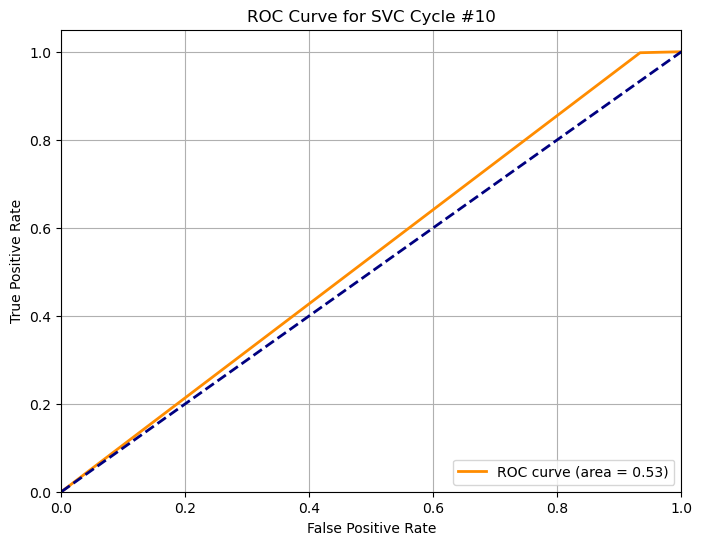

0.43811672563612647
0.30473336783484134
0.3299833340864198
0.0
0.3531784589674964
0.31894204873553456
0.24355420612390039
0.2788734426958283
0.20581600552588095
0.2232384470944476
RESULTS FOR CYCLE MLP#10
Accuracy: 0.9534
F1-Score: 0.9760
MCC: 0.1998


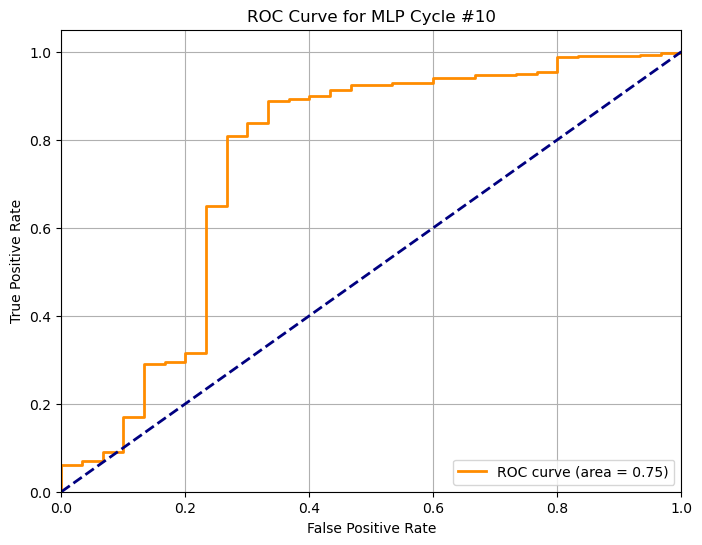

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# --- Metrics and plotting libraries ---
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix, matthews_corrcoef, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

pred_val_svc = []
pred_test_svc = []

pred_val_knn = []
pred_test_knn = []

pred_val_mlp = []
pred_test_mlp = []

# --- Your main loop starts here ---
for i in range(1,11):
    # Assuming 'mod_data' directory and files exist for demonstration
    # For a runnable example, you might need to create dummy CSV files
    # For instance:
    # pd.DataFrame(np.random.rand(100, 10)).to_csv(f"mod_data/X1.{i}", index_label="QSPRID")
    # pd.DataFrame(np.random.randint(0, 2, 100)).to_csv(f"mod_data/y1.{i}", index_label="QSPRID")
    # ... similarly for X2, X3, y2, y3
    x1 = pd.read_csv(f"mod_data/X1.{i}", index_col="QSPRID")
    x2 = pd.read_csv(f"mod_data/X2.{i}", index_col="QSPRID")
    x3 = pd.read_csv(f"mod_data/X3.{i}", index_col="QSPRID")
    y1 = pd.read_csv(f"mod_data/y1.{i}", index_col="QSPRID")
    y2 = pd.read_csv(f"mod_data/y2.{i}", index_col="QSPRID")
    y3 = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")



    x1.columns = x1.columns.astype(str)
    x2.columns = x2.columns.astype(str)
    x3.columns = x3.columns.astype(str)

    imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
    x1 = imp_mean.fit_transform(x1)
    x2 = imp_mean.transform(x2)
    x3 = imp_mean.transform(x3)
    scaler = StandardScaler()
    scaler.fit(x1)
    x1 = scaler.transform(x1)
    x2 = scaler.transform(x2)
    x3 = scaler.transform(x3)

    pca = PCA(n_components=0.95, random_state = 69)
    pca.fit(x1)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cum_var >= 0.95) + 1
    pca = PCA(n_components=n_components, random_state = 69)
    x1 = pca.fit_transform(x1)
    x2 = pca.transform(x2)
    x3 = pca.transform(x3)

    y1 =  y1.values.ravel()
    y2 = y2.values.ravel()
    y3 = y3.values.ravel()

    print("SVC")
    best_mcc_this_run_svc = -1
    best_val_results_this_run_svc = []
    best_test_results_this_run_svc = []
    for j in best_results_svc_dicts:
        j["gamma"]= j["gamma"] if j["gamma"] == 'auto' or j["gamma"] == 'scale' else float(j["gamma"])
        svc = SVC(**j, random_state=69)
        svc.fit(x1, y1)
        pred = svc.predict(x2)
        mcc = matthews_corrcoef(y2, pred) # pred is already binary for SVC.predict
        print(mcc)
        if mcc > best_mcc_this_run_svc:
            best_mcc_this_run_svc = mcc
            best_val_results_this_run_svc = svc.predict(x2)
            best_test_results_this_run_svc = svc.predict(x3)
    pred_val_svc.append(best_val_results_this_run_svc)
    pred_test_svc.append(best_test_results_this_run_svc)
    # Get binary predictions

    best_mcc_this_run = -1
    best_val_results_this_run = []
    best_test_results_this_run = []
    print("KNN")
    for j in best_results_knn_dicts:
        knn = KNeighborsClassifier(**j)
        knn.fit(x1, y1)
        pred = knn.predict(x2)
        mcc = matthews_corrcoef(y2, pred)
        print(mcc)
        if mcc > best_mcc_this_run:
            best_mcc_this_run = mcc
            best_val_results_this_run = knn.predict(x2)
            best_test_results_this_run = knn.predict(x3)
    pred_val_knn.append(best_val_results_this_run)
    pred_test_knn.append(best_test_results_this_run)

    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.

    pred = pred_test_knn[-1]
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE KNN#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)

    pred = pred_test_svc[-1]
    # SVC.predict returns binary labels, so pred_proba for ROC needs svc.decision_function or svc.predict_proba
    # For simplicity, if you only have predict, you can use the binary prediction for ROC, but it won't be smooth.
    # If SVC was trained with probability=True, you could use svc.predict_proba(x3)[:, 1]
    # For now, let's assume pred is already binary for metrics and use it for ROC (though not ideal for a smooth curve)
    pred_proba_svc = pred # Using binary prediction as "probability" for ROC, not ideal but avoids error
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE SVC#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print("="*30)
    # Calculate ROC curve and AUC
    # Note: For a proper ROC curve, you need probabilities, not binary predictions.
    # If SVC was initialized with `probability=True`, you could use `svc.predict_proba(x3)[:, 1]`.
    # As it is, `pred` is binary, so `roc_curve` will produce a step function.
    fpr, tpr, thresholds = roc_curve(y3, pred_proba_svc)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for SVC Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    best_mcc_this_run_mlp = -1
    best_val_results_this_run_mlp = []
    best_test_results_this_run_mlp = []
    for j in best_results_dicts:
        if isinstance(j["optimizer"], str):
            j["optimizer"] = eval("optim." + j["optimizer"])
        if isinstance(j["neuron_layers"], str):
            j["neuron_layers"] = eval(j["neuron_layers"])
        j["batch_size"] = int(j["batch_size"])
        j["n_epochs"] = int(j["n_epochs"])
        # Ensure 'cuda' is available or use 'cpu'
        device = "cuda" if torch.cuda.is_available() else "cpu"
        mlp = MultiLayerPerceptron(x1.shape[1], n_class=1,act_fun=F.selu, device=device, **j, seed=69)
        mlp.fit(x1, y1, x2,y2)
        # mlp.predict returns probabilities, so thresholding is needed for MCC
        pred_val_mlp_prob = mlp.predict(x2)
        pred = (pred_val_mlp_prob > 0.5).astype(int) # Convert boolean to int (0 or 1)
        mcc = matthews_corrcoef(y2, pred)
        print(mcc)
        if mcc > best_mcc_this_run_mlp: # Changed from best_mcc_this_run to best_mcc_this_run_mlp
            best_mcc_this_run_mlp = mcc
            best_val_results_this_run_mlp = pred_val_mlp_prob # Store probabilities
            best_test_results_this_run_mlp = mlp.predict(x3) # Store probabilities
    pred_val_mlp.append(best_val_results_this_run_mlp)
    pred_test_mlp.append(best_test_results_this_run_mlp)
    # Get binary predictions


    # --- Start: New code for metrics and plotting at the end of each cycle ---

    # I am assuming your model has a `predict_proba` method to get probabilities for the ROC curve.
    pred_proba = np.array(pred_test_mlp[-1]) # Convert the list to a NumPy array for element-wise comparison
    pred = (pred_proba > 0.5).astype(int) # Convert boolean to int (0 or 1)
    # Calculate all metrics for the current fold
    acc = accuracy_score(y3, pred)
    f1 = f1_score(y3, pred)
    mcc = matthews_corrcoef(y3, pred)

    # Print results for the current cycle
    print("="*30)
    print(f"RESULTS FOR CYCLE MLP#{i}")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")

    # Calculate ROC curve and AUC
    # pred_proba is already probabilities, so it's suitable for roc_curve
    fpr, tpr, thresholds = roc_curve(y3, pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current cycle
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for MLP Cycle #{i}')
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.show() # This will display the plot for the current cycle

    print("="*30)
    # --- End: New code ---
    # --- End: New code ----



In [25]:
df_existing_knn.iloc[:, :6]

,algorithm,leaf_size,metric,n_neighbors,p,weights
0,auto,10,euclidean,5,1,uniform
61,kd_tree,10,euclidean,5,1,distance
90,brute,10,euclidean,5,1,uniform
89,kd_tree,100,minkowski,5,2,distance
88,kd_tree,100,minkowski,5,2,uniform
87,kd_tree,100,euclidean,5,2,distance
86,kd_tree,100,euclidean,5,2,uniform
85,kd_tree,100,euclidean,5,1,distance
84,kd_tree,100,euclidean,5,1,uniform
83,kd_tree,50,minkowski,5,2,distance


In [40]:
all_y3 =[]
mcc_list = []
f1_list_mlp = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3.append(y_test)
    f1_list_mlp.append(f1_score(y_test, (pred_test_mlp[i-1]>0.5)))
    mcc_list.append(matthews_corrcoef(y_test, (pred_test_mlp[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [27]:
display(mcc_list)

[0.1281798780761299,
 0.27633194551789986,
 0.29321859804235006,
 0.14935675272967644,
 0.3122218820237701,
 0.18828640645456463,
 0.31953811194513976,
 0.16379161523982758,
 0.11243400302788535,
 0.1998145741868857]

In [28]:
display(all_y3)

[QSPRID
 A2ARDataset_000    False
 A2ARDataset_001     True
 A2ARDataset_002     True
 A2ARDataset_003     True
 A2ARDataset_004     True
                    ...  
 A2ARDataset_859     True
 A2ARDataset_860     True
 A2ARDataset_861     True
 A2ARDataset_862     True
 A2ARDataset_863     True
 Name: Y, Length: 864, dtype: bool,
 QSPRID
 A2ARDataset_000    False
 A2ARDataset_001     True
 A2ARDataset_002     True
 A2ARDataset_003     True
 A2ARDataset_004     True
                    ...  
 A2ARDataset_873     True
 A2ARDataset_874     True
 A2ARDataset_875     True
 A2ARDataset_876     True
 A2ARDataset_877     True
 Name: Y, Length: 878, dtype: bool,
 QSPRID
 A2ARDataset_000    False
 A2ARDataset_001     True
 A2ARDataset_002     True
 A2ARDataset_003     True
 A2ARDataset_004     True
                    ...  
 A2ARDataset_867     True
 A2ARDataset_868     True
 A2ARDataset_869     True
 A2ARDataset_870     True
 A2ARDataset_871     True
 Name: Y, Length: 872, dtype: bool,
 QSPRID
 A

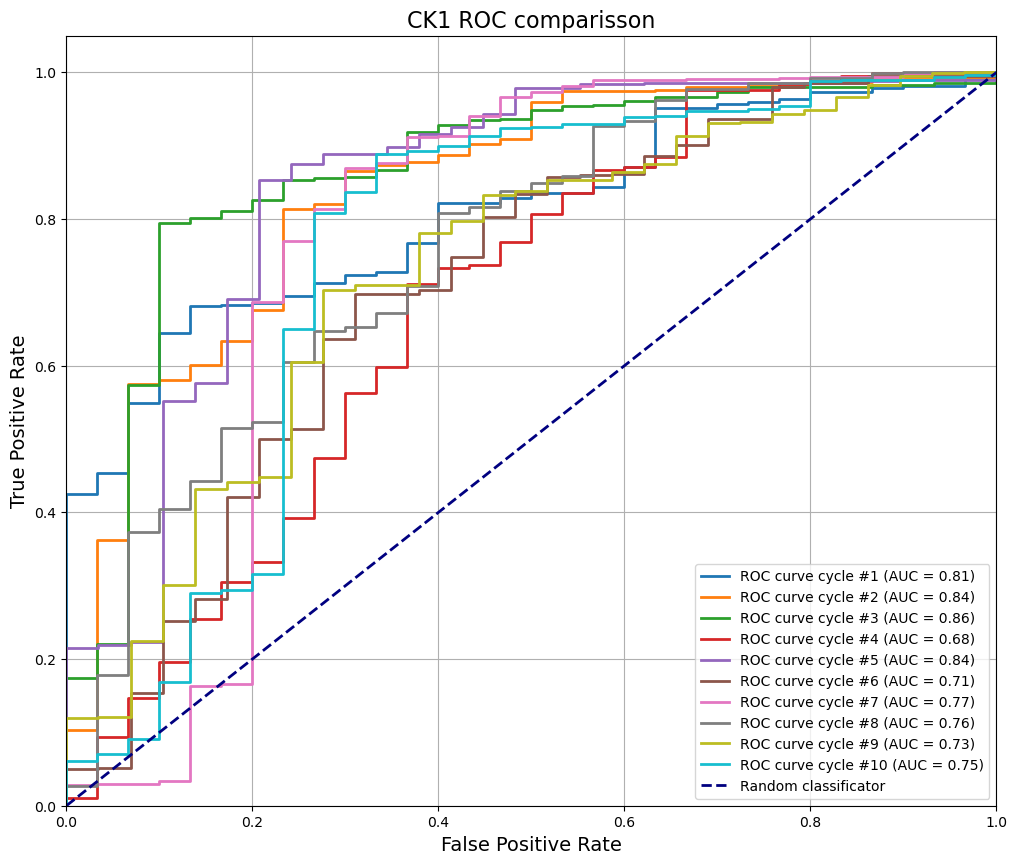

In [29]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"



plt.figure(figsize=(12, 10))

# Projdeme všechny uložené predikce a skutečné hodnoty
for i in range(len(pred_test_mlp)):
    
    # Získáme data pro i-tý cyklus
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    # Vypočítáme ROC křivku a AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Vykreslíme křivku pro tento cyklus do společného grafu
    # (i + 2) použijeme pro správné číslování cyklů, protože váš cyklus začínal od 2
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve cycle #{i + 1} (AUC = {roc_auc:.2f})')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classificator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('CK1 ROC comparisson', fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

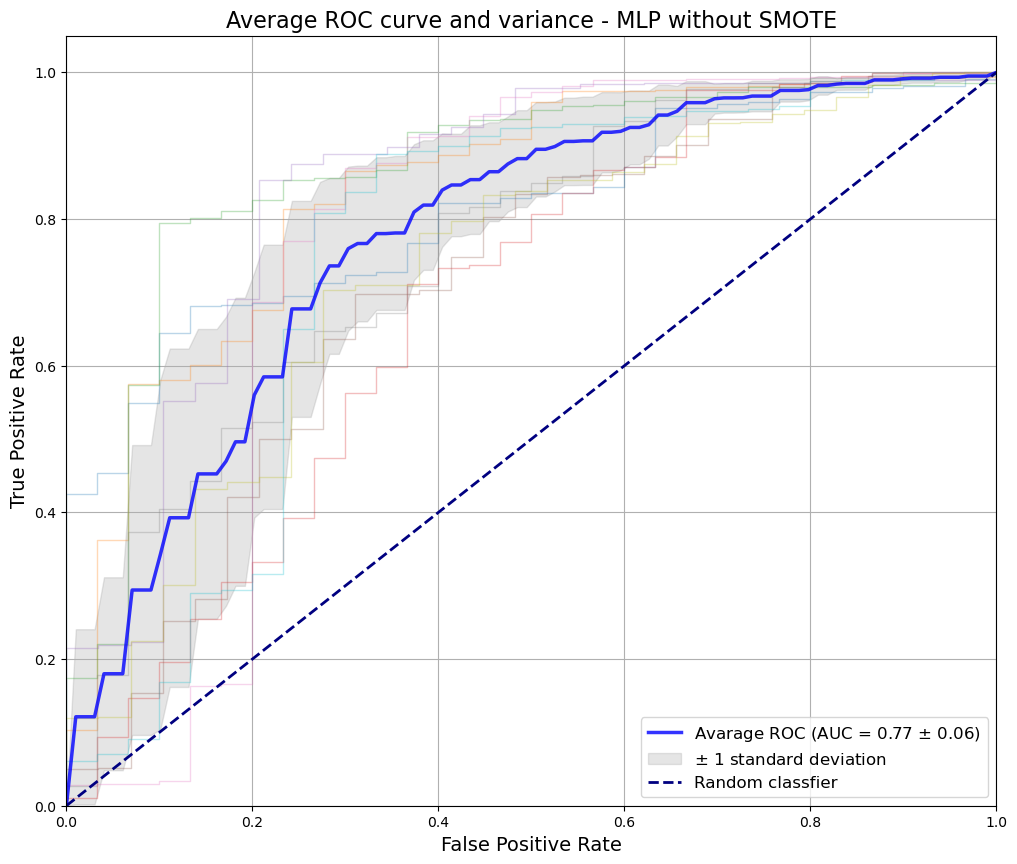

In [42]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3[i]
    y_pred_proba = pred_test_mlp[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.savefig('mcc_roc_a2ar_ws.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
all_y3_knn =[]
mcc_list_knn = []
f1_list_knn = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_knn.append(y_test)
    f1_list_knn.append(f1_score(y_test, (pred_test_knn[i-1]>0.5)))
    mcc_list_knn.append(matthews_corrcoef(y_test, (pred_test_knn[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


In [39]:
all_y3_svc =[]
mcc_list_svc = []
f1_list_svc = []
for i in range(1,11):
    print(i)
    y_test = pd.read_csv(f"mod_data/y3.{i}", index_col="QSPRID")
    y_test = y_test["Y"]
    all_y3_svc.append(y_test)
    f1_list_svc.append(f1_score(y_test, (pred_test_svc[i-1]>0.5)))
    mcc_list_svc.append(matthews_corrcoef(y_test, (pred_test_svc[i-1]>0.5)))

1
2
3
4
5
6
7
8
9
10


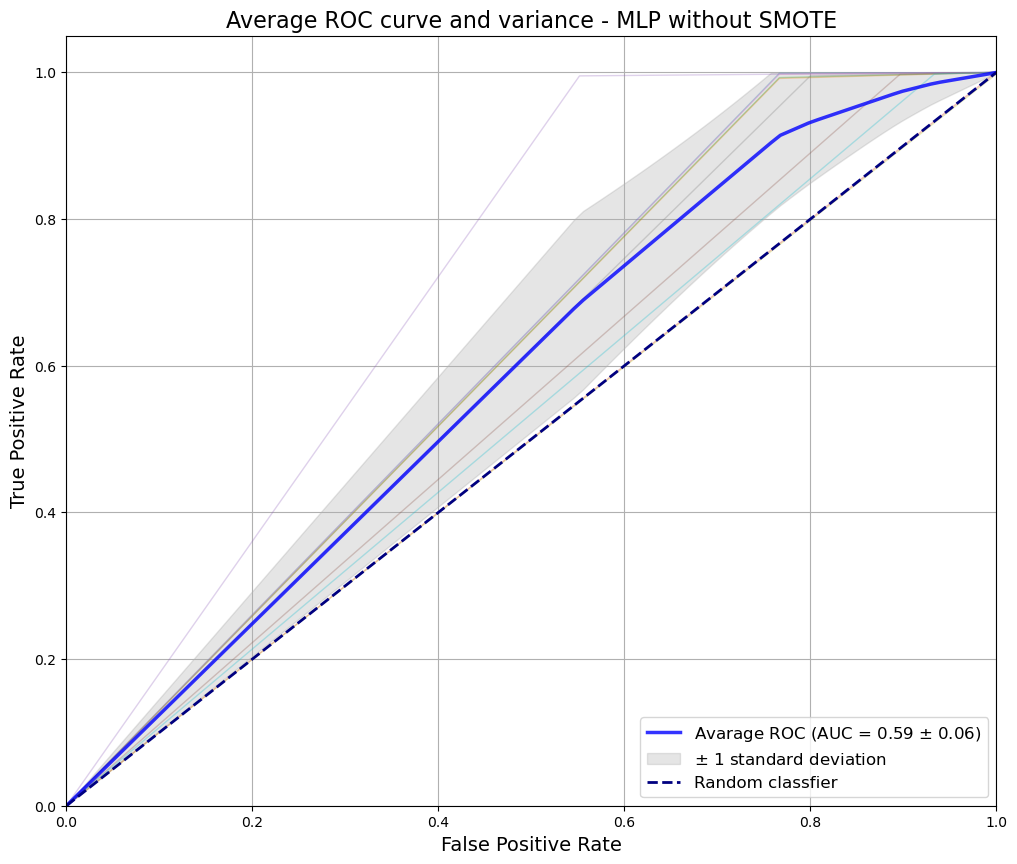

In [33]:
# Tento kód vložte až ZA váš hlavní cyklus "for i in range(2, 11):"

# Seznamy pro ukládání výsledků pro průměrování
tprs = []
aucs = []
# Vytvoření společné osy X (False Positive Rate) pro interpolaci
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(12, 10))

# Cyklus pro výpočet a vykreslení jednotlivých křivek
for i in range(len(pred_test_mlp)):
    y_true = all_y3_svc[i]
    y_pred_proba = pred_test_svc[i]
    
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Vykreslení jednotlivých křivek (volitelné, s menší viditelností)
    plt.plot(fpr, tpr, lw=1, alpha=0.3)
             
    # Interpolace TPR na společné ose mean_fpr a uložení
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

# Výpočet průměrné křivky a směrodatné odchylky
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Zajistíme, že křivka končí v bodě [1,1]
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Vykreslení průměrné křivky
plt.plot(mean_fpr, mean_tpr, color='b',
         label=fr'Avarage ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2.5, alpha=.8)

# Vykreslení pásma směrodatné odchylky
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 standard deviation')

# Dokončení grafu
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classfier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Average ROC curve and variance - MLP without SMOTE', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)
plt.show()

/tmp/ipykernel_28404/1026737167.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot([mcc_list, mcc_list_knn, mcc_list_svc], patch_artist=True, labels=['MLP', "KNN", "SVM"])


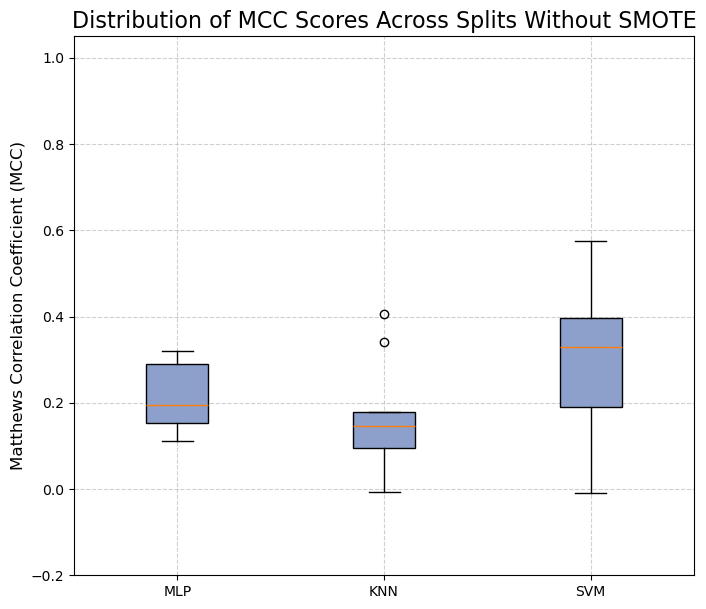

In [34]:
import matplotlib.pyplot as plt

# --- Code to generate a boxplot specifically for MCC scores ---

plt.figure(figsize=(8, 7))

# Create a boxplot for the collected MCC values
# patch_artist=True allows us to color the box
bplot = plt.boxplot([mcc_list, mcc_list_knn, mcc_list_svc], patch_artist=True, labels=['MLP', "KNN", "SVM"])
# Add titles and labels in English
plt.title('Distribution of MCC Scores Across Splits Without SMOTE', fontsize=16)
plt.ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)

# MCC scores range from -1 to 1.
# Set the y-axis limits to represent this full range.
plt.ylim([-0.2, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)

# Set a single color for all boxes
box_color = '#8da0cb'  # You can choose any color you like

for box in bplot['boxes']:
    box.set_facecolor(box_color)

plt.show()

In [35]:
[mcc_list, mcc_list_knn, mcc_list_svc]

[[0.1281798780761299,
  0.27633194551789986,
  0.29321859804235006,
  0.14935675272967644,
  0.3122218820237701,
  0.18828640645456463,
  0.31953811194513976,
  0.16379161523982758,
  0.11243400302788535,
  0.1998145741868857],
 [0.17332578285850453,
  0.17953019478623866,
  0.12403710255014591,
  -0.006307414036197334,
  0.1392570156212914,
  -0.006284578193275152,
  0.15223657127683576,
  0.4061637774155975,
  0.34173701316387467,
  0.08636823648308975],
 [0.4437119029360156,
  0.3264163477008382,
  0.3402164470726091,
  0.0,
  0.5751772174309716,
  0.2400299353933224,
  0.41642937883652664,
  0.33437662462636963,
  -0.008830963679450526,
  0.17371209956807496]]

In [41]:
[f1_list_mlp, f1_list_knn, f1_list_svc]

[[0.9209361163820367,
  0.9186119873817035,
  0.9688249400479616,
  0.9153175591531756,
  0.931316950220542,
  0.9800235017626322,
  0.9464508094645081,
  0.9046114971572963,
  0.965026674570243,
  0.9759725400457666],
 [0.9822904368358913,
  0.9831884057971014,
  0.9806678383128296,
  0.982153137593552,
  0.9817968291250734,
  0.9824970828471412,
  0.9817109144542773,
  0.9855240301100173,
  0.9848837209302326,
  0.9784090909090909],
 [0.9857988165680474,
  0.9824766355140186,
  0.9829512051734274,
  0.9827387802071347,
  0.9881796690307328,
  0.9836257309941521,
  0.9852158486102898,
  0.9837587006960556,
  0.9820289855072464,
  0.9830316742081447]]